# Foveation on a Natural Image

Foveation keeps high resolution near fixation and increases blur with eccentricity:
$$
\sigma(x)=\sigma_0+\beta\,\|x-x_f\|.
$$
We apply it to a natural image for multiple fixation points and radii.


## Natural image and radial blur blending


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

from matplotlib.cbook import get_sample_data
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter

OUT = Path("python/foveation"); OUT.mkdir(parents=True, exist_ok=True)
img = mpimg.imread(get_sample_data("grace_hopper.jpg")).astype(float)
if img.max() > 1:
    img /= 255.0
img = img[120:620, 100:800, :3]
h, w, _ = img.shape
Y, X = np.mgrid[0:h, 0:w]

def foveate(image, center, radius):
    cx, cy = center
    d = np.sqrt((X-cx)**2 + (Y-cy)**2)
    m1 = np.clip(1 - d/radius, 0, 1)[..., None]
    b1 = gaussian_filter(image, sigma=(1.4, 1.4, 0))
    b2 = gaussian_filter(image, sigma=(4.0, 4.0, 0))
    b3 = gaussian_filter(image, sigma=(9.0, 9.0, 0))
    m2 = np.clip(1 - d/(1.9*radius), 0, 1)[..., None]
    return m1*image + (m2-m1)*b1 + (1-m2)*(0.45*b2 + 0.55*b3)

views = [
    ("fix=(0.30W,0.55H), r=120", foveate(img, (0.30*w, 0.55*h), 120)),
    ("fix=(0.65W,0.38H), r=95", foveate(img, (0.65*w, 0.38*h), 95)),
    ("fix=(0.52W,0.70H), r=150", foveate(img, (0.52*w, 0.70*h), 150)),
]


## Foveation at different locations and radii


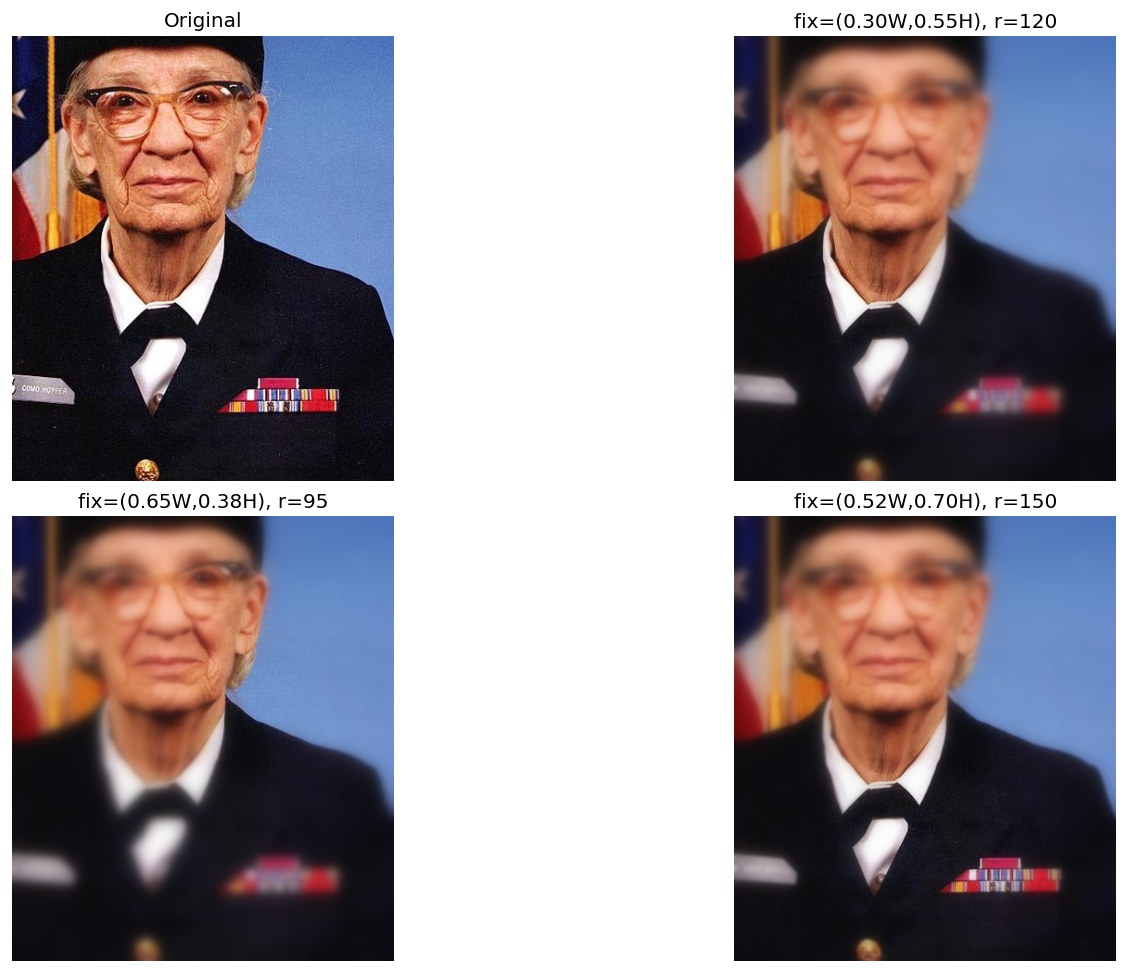

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0), constrained_layout=True)
axes[0,0].imshow(img); axes[0,0].set_title("Original")
for ax, (ttl, v) in zip([axes[0,1], axes[1,0], axes[1,1]], views):
    ax.imshow(v); ax.set_title(ttl)
for ax in axes.ravel():
    ax.axis("off")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
